In [1]:
#Imports — modelling.py contains all custom functions (compare_models, tune_model, etc.)

import pandas as pd
import modelling as ml
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

In [2]:
#Load pre-processed train/test sets saved from feature engineering notebook
#squeeze() converts single-column DataFrames to Series for compatibility with sklearn

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").squeeze()
y_train = pd.read_csv("y_train.csv").squeeze()

In [3]:
#Reset index after loading from CSV

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [17]:
#Add target lag features since the previous grade is legitimately available to operators
# and captures the strong temporal autocorrelation found in feature engineering

X_train['iron_conc_lag1'] = y_train.shift(1).fillna(y_train.mean())
X_train['iron_conc_rolling_3h'] = y_train.shift(1).rolling(3).mean().fillna(y_train.mean())

X_test['iron_conc_lag1'] = y_test.shift(1).fillna(y_train.mean())
X_test['iron_conc_rolling_3h'] = y_test.shift(1).rolling(3).mean().fillna(y_train.mean())

X_train['iron_conc_rolling_6h'] = y_train.shift(1).rolling(6).mean().fillna(y_train.mean())
X_test['iron_conc_rolling_6h'] = y_test.shift(1).rolling(6).mean().fillna(y_train.mean())


/var/folders/5r/56m82rjn5cqdmz3b771c5t8c0000gn/T/ipykernel_67589/3333721280.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['iron_conc_rolling_6h'] = y_train.shift(1).rolling(6).mean().fillna(y_train.mean())


In [14]:
#TimeSeriesSplit with 7 folds. Tested 3, 5, 7; 7 gave most stable scores

tscv = TimeSeriesSplit(n_splits=7)

In [15]:
#Instantiate baseline models. Decision Tree as simple baseline,
#Random Forest (bagging) and XGBoost (boosting) as main candidates

rf_model = RandomForestRegressor(random_state=42)
xgb_model = XGBRegressor(random_state=42)
tree_model = DecisionTreeRegressor

models = {"tree_model":DecisionTreeRegressor(random_state=42, max_depth=5, min_samples_leaf=10),
          "rf_model":RandomForestRegressor(n_estimators=100, random_state=42),
          "xgb_model":XGBRegressor(n_estimators=100, random_state=42)}

In [18]:
#Baseline comparison
#Establishes which models are worth tuning

ml.compare_models(models, X_train, y_train, X_test, y_test, tscv)

,Model,CV R² (mean),CV R² (std),Test R²,Test MAE
1,rf_model,0.429,0.111,0.506,0.593
2,xgb_model,0.328,0.121,0.444,0.629
0,tree_model,0.359,0.130,0.443,0.612


In [19]:
#Hyperparameter grids for GridSearchCV
#RF: controlling tree depth and split size to prevent overfitting
#XGB: low learning rate and subsampling to handle noisy industrial data

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

In [20]:
#Tune Random Forest

best_rf = ml.tune_model(rf_model, param_grid_rf, X_train, y_train, X_test, y_test, tscv)

Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.477
Test R²: 0.525
Test MAE: 0.571


In [21]:
#Tune XGB

best_xgb = ml.tune_model(xgb_model, param_grid_xgb, X_train, y_train, X_test, y_test, tscv)

Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV R²: 0.476
Test R²: 0.536
Test MAE: 0.563


In [22]:
## Feature importance for XGBoost and compare with RF to identify consistently important features

ml.feature_importance(best_rf, X_train, top_n=15)

iron_conc_lag1                       0.837098
iron_conc_rolling_3h                 0.061573
iron_conc_rolling_6h                 0.008246
flotation_column_04_level_min        0.003247
flotation_column_06_level_std        0.002878
starch_flow_mean_lag1                0.002682
flotation_column_02_air_flow_max     0.002650
ore_pulp_ph_mean_lag1                0.002626
ore_pulp_ph_mean_rolling_mean_3h     0.002453
flotation_column_03_air_flow_max     0.002006
time_idx                             0.001914
ore_pulp_ph_mean_lag3                0.001760
flotation_column_02_air_flow_mean    0.001647
flotation_column_03_level_mean       0.001646
ore_pulp_ph_max                      0.001637
dtype: float64

In [23]:
ml.feature_importance(best_xgb, X_train, top_n=15)

iron_conc_lag1                        0.143521
iron_conc_rolling_3h                  0.054055
iron_conc_rolling_6h                  0.014849
pct_iron_feed_mean_lag1               0.013584
ore_pulp_ph_mean_rolling_mean_3h      0.011889
ore_pulp_ph_mean_lag1                 0.010899
ore_pulp_ph_mean_lag3                 0.010087
flotation_column_02_level_std         0.010012
pct_iron_feed_mean_rolling_mean_3h    0.009946
flotation_column_07_level_max         0.009800
flotation_column_01_level_std         0.009790
flotation_column_01_air_flow_max      0.009608
level_total_std                       0.009555
starch_flow_std                       0.009512
flotation_column_04_level_min         0.009343
dtype: float32

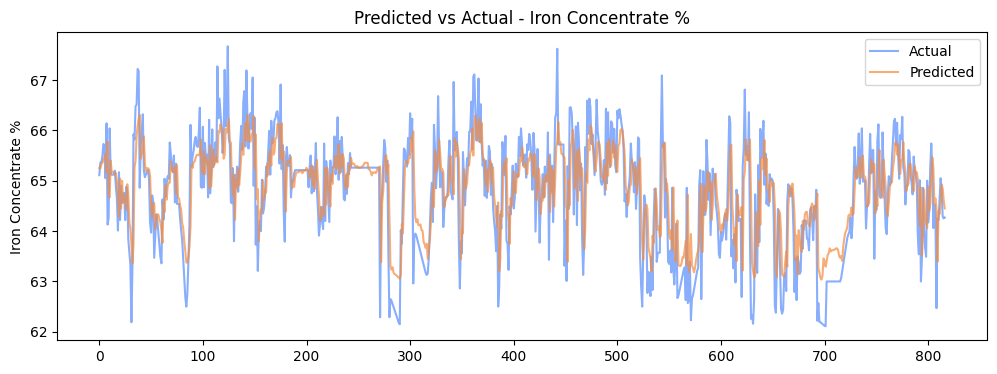

In [24]:
# Predicted vs actual for XGBoost. Visualization of model behaviour over the test period

ml.plot_predictions(best_xgb, X_test, y_test)

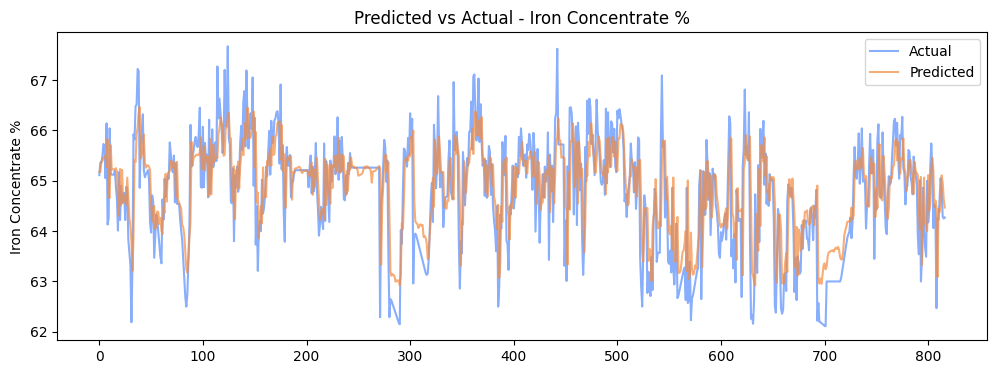

In [25]:
# Predicted vs actual for Random Forest. Visualization of model behaviour over the test period

ml.plot_predictions(best_rf, X_test, y_test)